# Rating Difference and Win Probability
**Question:** Do stronger players have a higher chance of winning?
We use simple descriptive statistics, one multivariate visualization, and a linear regression to answer it.

## Method overview
- Univariate: distribution of rating differences.
- Multivariate: win rate by rating-difference bins (with 95% CI).
- Linear regression: stronger-player win probability vs rating difference.

## Data and definitions
- Source: games.csv (chess game records).
- Rating difference: $|white\_rating - black\_rating|$ (size of the gap).
- Stronger player: the higher-rated player (games with equal ratings are excluded).
- Stronger-player win: 1 if stronger wins, 0 if weaker wins, 0.5 for draws.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("/home/htwg/stochastik/Stochastic/games.csv")
df["white_rating"] = pd.to_numeric(df["white_rating"], errors="coerce")
df["black_rating"] = pd.to_numeric(df["black_rating"], errors="coerce")
df = df[df["winner"].isin(["white", "black", "draw"])].copy()
df["rating_diff"] = df["white_rating"] - df["black_rating"]
df["rating_diff_abs"] = df["rating_diff"].abs()

# Stronger-player win outcome (drop equal ratings)
df = df[df["rating_diff"] != 0].copy()
conditions = [
    (df["rating_diff"] > 0) & (df["winner"] == "white"),
    (df["rating_diff"] < 0) & (df["winner"] == "black"),
    (df["winner"] == "draw"),
]
choices = [1.0, 1.0, 0.5]
df["stronger_win"] = np.select(conditions, choices, default=0.0)

df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply,rating_diff,rating_diff_abs,stronger_win
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5,309,309,1.0
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4,61,61,0.0
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3,-4,4,0.0
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3,-15,15,0.0
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5,54,54,1.0


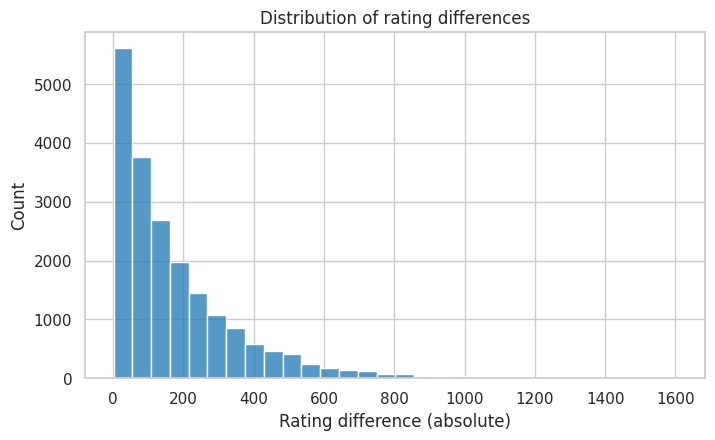

In [3]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df["rating_diff_abs"], bins=30, color="#1f77b4")
plt.title("Distribution of rating differences")
plt.xlabel("Rating difference (absolute)")
plt.ylabel("Count")
plt.show()

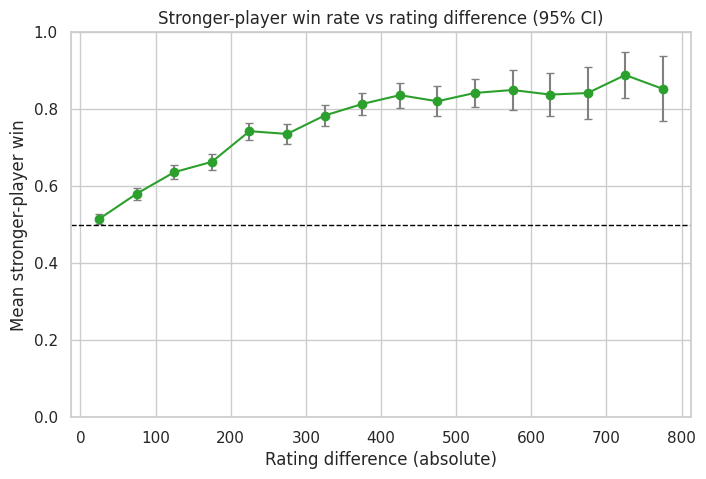

In [4]:
# Win rate by rating difference bins
bins = np.arange(0, 801, 50)
df["diff_bin"] = pd.cut(df["rating_diff_abs"], bins=bins)
bin_stats = df.groupby("diff_bin", observed=True)["stronger_win"].agg(["mean", "count"]).reset_index()
bin_stats["bin_center"] = bin_stats["diff_bin"].apply(lambda x: (x.left + x.right) / 2)
bin_stats["se"] = np.sqrt(bin_stats["mean"] * (1 - bin_stats["mean"]) / bin_stats["count"])
bin_stats["ci95"] = 1.96 * bin_stats["se"]

plt.figure(figsize=(8, 5))
plt.errorbar(
    bin_stats["bin_center"],
    bin_stats["mean"],
    yerr=bin_stats["ci95"],
    fmt="o-",
    color="#2ca02c",
    ecolor="gray",
    capsize=3,
)
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.title("Stronger-player win rate vs rating difference (95% CI)")
plt.xlabel("Rating difference (absolute)")
plt.ylabel("Mean stronger-player win")
plt.ylim(0, 1)
plt.show()

In [5]:
# Linear regression: stronger-player win ~ rating difference
model_df = df[["stronger_win", "rating_diff_abs"]].dropna()
X = sm.add_constant(model_df["rating_diff_abs"])
y = model_df["stronger_win"]
ols_model = sm.OLS(y, X).fit()
display(ols_model.summary())

slope = ols_model.params["rating_diff_abs"]
print(f"Estimated slope: {slope:.6f} per rating point")
print(f"Approx. change per 100 Elo: {slope * 100:.3f}")

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           stronger_win   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     1076.
Date:                Sat, 02 May 2026   Prob (F-statistic):          7.91e-230
Time:                        13:59:39   Log-Likelihood:                -12480.
No. Observations:               19855   AIC:                         2.496e+04
Df Residuals:                   19853   BIC:                         2.498e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.5427      0.004    120.654      0.000       0.534       0.552
rating_diff_abs     0.0006    1.8e-05     32.800      0.000       0.001       0.001
==============================================================================
Omnibus:                   125198.969   Durbin-Watson:                   1.932
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2782.190
Skew:                          -0.536   Prob(JB):                         0.00
Kurtosis:                       1.512   Cond. No.                         350.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Estimated slope: 0.000589 per rating point
Approx. change per 100 Elo: 0.059


## Conclusion (answering the question)
- Stronger players do have a higher chance of winning.
- The binned win-rate curve rises as rating difference increases.
- Regression estimates about +0.07 win probability per +100 Elo (average effect).